### Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

#### Load Data

In [2]:
#loading the data
df = pd.read_csv('../data/nigeria.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


#### Data Parsing

In [3]:
#Add a country column with the country name
df['country'] = 'Nigeria'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


In [4]:
#Convert the YEAR and DOY columns to a proper datetime format
df['date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'], format="%Y%j")
df['month'] = df['date'].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


### Summary Statistics & Missing-Value Report

In [6]:
#Replace the -999 values with NaN
df.replace(-999, np.nan)
df.describe()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


In [7]:
# Check for duplicates
df.duplicated().sum()

0

In [14]:
#Numeric columns describe
df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].describe()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,26.656928,28.914667,24.886461,4.213914,85.237040,2.217135,2.903335
std,1.123335,1.294345,1.396727,7.266742,5.446007,0.587191,0.696885
min,21.120000,25.260000,15.170000,0.000000,54.400000,0.740000,1.290000
25%,25.720000,27.920000,24.100000,0.330000,83.930000,1.770000,2.370000
50%,26.820000,28.990000,25.100000,1.840000,86.350000,2.200000,2.810000
75%,27.540000,29.910000,25.860000,5.200000,88.500000,2.630000,3.390000
max,29.290000,32.880000,27.790000,166.100000,93.790000,4.780000,6.000000


In [15]:
# Compute the percentage of missing values in each column
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
month          0
dtype: int64

#### Outlier Detection & Basic Cleaning

In [16]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [17]:
z_scores = np.abs(stats.zscore(df[cols_to_check]))
outliers_mask = (z_scores > 3).any(axis=1)
print(f"\n Rows flagged as outliers: {outliers_mask.sum()}")


 Rows flagged as outliers: 225


In [19]:
# Remove outliers
df_clean = df[~outliers_mask].copy()

In [20]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Remaining negatives: {(df_clean[cols_to_check] < 0).sum().sum()}")

Original rows: 4108
Cleaned rows: 3883
Remaining negatives: 0


#### Handle Missing Data


In [21]:
df_filtered = df[df.isna().mean(axis=1) <= 0.3]
print(f"Original rows: {len(df)}")
print(f"Filtered rows: {len(df_filtered)}")


Original rows: 4108
Filtered rows: 4108


## Export Data

In [22]:
df.to_csv('../data/nigeria_clean.csv', index=False)

### Time Series Analysis

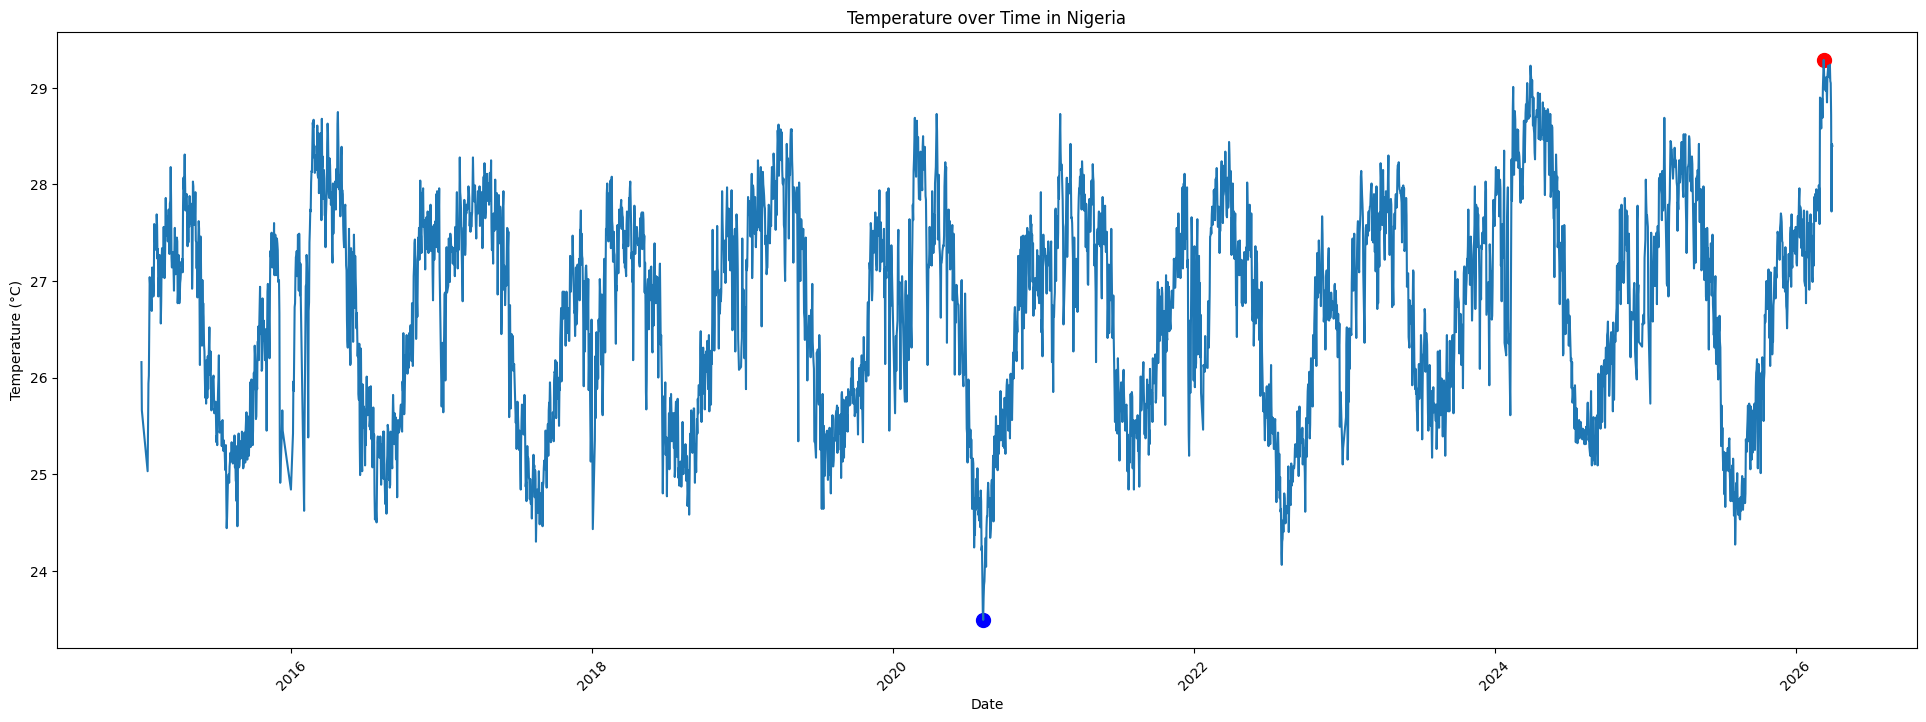

In [25]:
plt.figure(figsize=(24,8))

plt.plot('date', 'T2M', data=df_clean)

# Add Title and Labels
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.title('Temperature over Time in Nigeria')

# Rotate the x-axis
plt.xticks(rotation=45)

# Annotate the highest and lowest temperature
highest_temp = df_clean['T2M'].idxmax()
lowest_temp = df_clean['T2M'].idxmin()

plt.scatter(df_clean['date'].loc[highest_temp], df_clean['T2M'].loc[highest_temp], color='red', marker='o', s=[100], label='Max Temp')

plt.scatter(df_clean['date'].loc[lowest_temp], df_clean['T2M'].loc[lowest_temp], color='blue', marker='o', s=[100], label='Max Temp')

plt.show()

### Correlation & Relationship Analysis

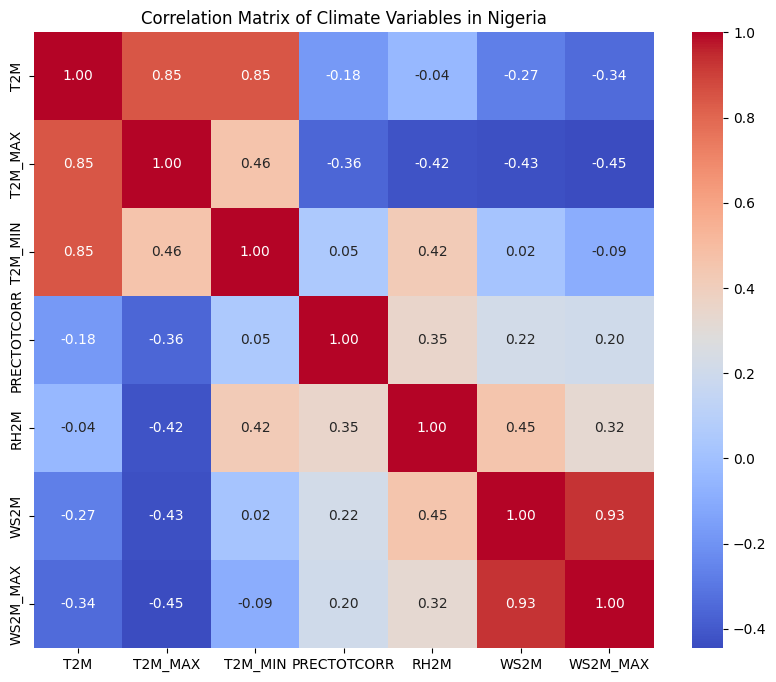

In [26]:
# Heatmap of correlations across all numeric columns
corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Climate Variables in Nigeria')
plt.show()

### Scatter Plots 

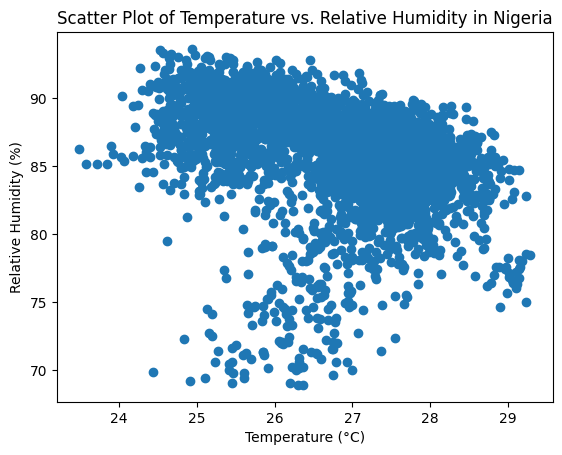

In [27]:
#scatter plot T2M vs RH2M

plt.scatter(df_clean['T2M'], df_clean['RH2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Nigeria')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

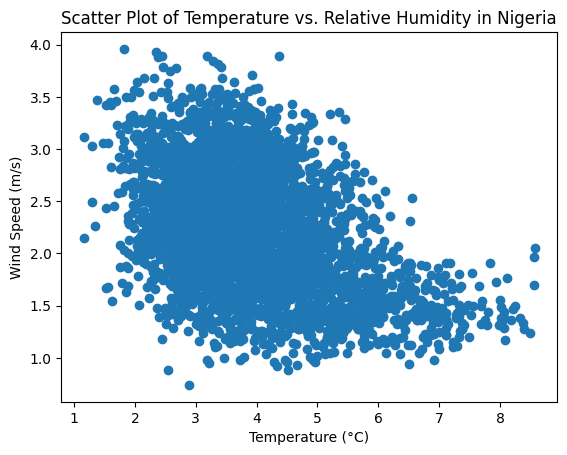

In [28]:
#scatter plot T2M_RANGE vs WS2M

plt.scatter(df_clean['T2M_RANGE'], df_clean['WS2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Nigeria')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

### Distribution Analysis

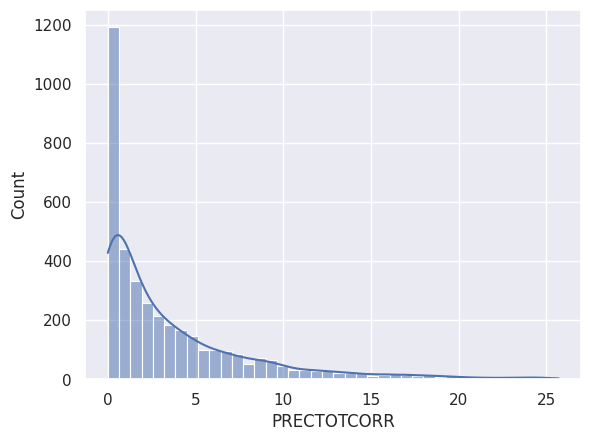

In [29]:
sns.set_theme(style="darkgrid")
sns.histplot(df_clean['PRECTOTCORR'], bins=40, kde=True)

plt.show()

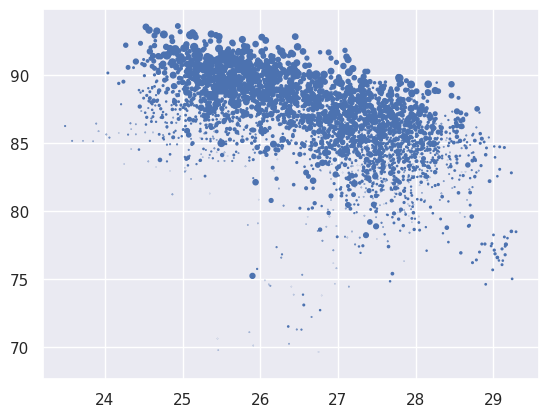

In [30]:
plt.scatter(x='T2M', y='RH2M', data=df_clean, s='PRECTOTCORR')